# CDD - Lab2

EDA, Histogramas, Sumarizacao.ipynb

## Instruções

Individual, em dupla ou em grupos de 3 alunos.

Quando for feito por mais de um aluno:

*   Todos enviam uma cópia idêntica; OU
*   Um aluno envia uma cópia completa e os demais enviam uma cópia vazia, indicando apenas o grupo e onde está a solução (informe isso na próxima célula).

**Implementações Extras.**
Implemente apenas o que é pedido (a quantidade de gráficos, por exemplo). Caso queria implementar algo mais, deixe separado no final do notebook (existe uma seção de rascunho já criada para isso).

**Implementação em duas etapas.** Parte A: do início até antes de "correlação".  Parte B: correlação será implementada apenas na próxima semana, após a aula sobre o assunto.




# Parte A

## Preencher:

**Aluno(as):**
Orlando Virginio Penha Junior - 122210927


**Forma de Envio (escolha uma das linhas a seguir e apague as demais):**.

Esta atividade foi feita individulamente (não fiz em grupo).

## Datsets

1. Rain in Australia

https://www.kaggle.com/jsphyg/weather-dataset-rattle-package?select=weatherAUS.csv

2. Student Food Survey

https://www.kaggle.com/mlomuscio/student-food-survey

3. Students Performance in Exams

https://www.kaggle.com/spscientist/students-performance-in-exams

### Informe aqui o datset escolhido:

1

## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
import kagglehub

/home/orlandojunior/miniconda3/envs/kaggle/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Carregando o dataset

In [2]:
path = kagglehub.dataset_download("jsphyg/weather-dataset-rattle-package")

print("Path to dataset files:", path)

Path to dataset files: /home/orlandojunior/.cache/kagglehub/datasets/jsphyg/weather-dataset-rattle-package/versions/2


In [3]:
df_rain = pd.read_csv(f'{path}/weatherAUS.csv')

## Inspeção Inicial dos Dados, Pré-processamento, limpeza, transformações, etc

Fique à vontade para criar descrições aninhadas aqui. Para ficarem aninhados, use títulos markdown de 3o nível (###) em diante.

### Leitura inicial do DataFrame

In [4]:
df_rain.info()

<class 'pandas.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  str    
 1   Location       145460 non-null  str    
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  str    
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  str    
 10  WindDir3pm     141232 non-null  str    
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null   float64


In [5]:
df_rain.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [6]:
df_rain.tail()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
145455,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,...,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,...,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,...,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No
145458,2017-06-24,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,...,51.0,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0,No,No
145459,2017-06-25,Uluru,14.9,NaN,0.0,NaN,NaN,NaN,NaN,ESE,...,62.0,36.0,1020.2,1017.9,8.0,8.0,15.0,20.9,No,NaN


In [7]:
df_rain.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


### Verificação de dados nulos

- Estratégia escolhida para trabalhar com dados nulos:
  - Colunas com mais do que 38% dos valores nulos foram retiradas do dataframe.
  - As linhas nulas de RainTomorrow foram excluídas. Já que, se o objetivo da análise for entender os fatores que levam á uma previsão de chuva, não faz sentido manter os valores dessas previsões que estão vazios/nulos.
  - Colunas com baixo percentual de nulos (<11%) terão seus valores preenchidos (média/ moda)

- Essa estratégia foi pensada para manter o máximo de dados possível. Caso fosse usado uma estratégia de remoção de linhas para valores nulos, quase 50% do dataset seria perdido. Dessa forma, julguei como melhor abordagem essa divisão de ações com base no percentual de valores nulos.


In [8]:
print(f'valores nulos:\n{(df_rain.isnull().sum()/len(df_rain) * 100).sort_values(ascending=False)}')

valores nulos:
Sunshine         48.009762
Evaporation      43.166506
Cloud3pm         40.807095
Cloud9am         38.421559
Pressure9am      10.356799
Pressure3pm      10.331363
WindDir9am        7.263853
WindGustDir       7.098859
WindGustSpeed     7.055548
Humidity3pm       3.098446
WindDir3pm        2.906641
Temp3pm           2.481094
RainTomorrow      2.245978
Rainfall          2.241853
RainToday         2.241853
WindSpeed3pm      2.105046
Humidity9am       1.824557
WindSpeed9am      1.214767
Temp9am           1.214767
MinTemp           1.020899
MaxTemp           0.866905
Date              0.000000
Location          0.000000
dtype: float64


In [9]:
df_rain = df_rain.dropna(subset=['RainTomorrow'])
print(f'valores nulos:\n{(df_rain.isnull().sum()/len(df_rain) * 100).sort_values(ascending=False)}')

valores nulos:
Sunshine         47.692924
Evaporation      42.789026
Cloud3pm         40.152469
Cloud9am         37.735332
Pressure9am       9.855619
Pressure3pm       9.832411
WindDir9am        7.041838
WindGustDir       6.561504
WindGustSpeed     6.519308
WindDir3pm        2.656952
Humidity3pm       2.538803
Temp3pm           1.917113
WindSpeed3pm      1.849599
Humidity9am       1.247600
Rainfall          0.988797
RainToday         0.988797
WindSpeed9am      0.948007
Temp9am           0.635756
MinTemp           0.447983
MaxTemp           0.226453
Location          0.000000
Date              0.000000
RainTomorrow      0.000000
dtype: float64


In [10]:
cols_to_drop = ['Sunshine', 'Evaporation', 'Cloud3pm', 'Cloud9am']
df_rain = df_rain.drop(columns=cols_to_drop)
print(f'valores nulos:\n{(df_rain.isnull().sum()/len(df_rain) * 100).sort_values(ascending=False)}')

valores nulos:
Pressure9am      9.855619
Pressure3pm      9.832411
WindDir9am       7.041838
WindGustDir      6.561504
WindGustSpeed    6.519308
WindDir3pm       2.656952
Humidity3pm      2.538803
Temp3pm          1.917113
WindSpeed3pm     1.849599
Humidity9am      1.247600
Rainfall         0.988797
RainToday        0.988797
WindSpeed9am     0.948007
Temp9am          0.635756
MinTemp          0.447983
MaxTemp          0.226453
Date             0.000000
Location         0.000000
RainTomorrow     0.000000
dtype: float64


In [11]:
features_media = [
    'Pressure9am', 'Pressure3pm', 'WindGustSpeed', 'WindSpeed3pm',
    'WindSpeed9am', 'Humidity3pm', 'Humidity9am', 'Temp3pm',
    'Temp9am', 'MinTemp', 'MaxTemp', 'Rainfall'
]

features_moda = [
    'WindDir9am', 'WindGustDir', 'WindDir3pm', 'RainToday'
]

imputer_mean = SimpleImputer(missing_values=np.nan, strategy='mean')
imputer_mode = SimpleImputer(missing_values=np.nan, strategy='most_frequent')

df_rain[features_media] = imputer_mean.fit_transform(df_rain[features_media])
df_rain[features_moda] = imputer_mode.fit_transform(df_rain[features_moda])

df_rain.info()


<class 'pandas.DataFrame'>
Index: 142193 entries, 0 to 145458
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           142193 non-null  str    
 1   Location       142193 non-null  str    
 2   MinTemp        142193 non-null  float64
 3   MaxTemp        142193 non-null  float64
 4   Rainfall       142193 non-null  float64
 5   WindGustDir    142193 non-null  str    
 6   WindGustSpeed  142193 non-null  float64
 7   WindDir9am     142193 non-null  str    
 8   WindDir3pm     142193 non-null  str    
 9   WindSpeed9am   142193 non-null  float64
 10  WindSpeed3pm   142193 non-null  float64
 11  Humidity9am    142193 non-null  float64
 12  Humidity3pm    142193 non-null  float64
 13  Pressure9am    142193 non-null  float64
 14  Pressure3pm    142193 non-null  float64
 15  Temp9am        142193 non-null  float64
 16  Temp3pm        142193 non-null  float64
 17  RainToday      142193 non-null  str    
 18  

In [12]:
print(f'valores nulos:\n{(df_rain.isnull().sum()/len(df_rain) * 100).sort_values(ascending=False)}')

valores nulos:
Date             0.0
Location         0.0
MinTemp          0.0
MaxTemp          0.0
Rainfall         0.0
WindGustDir      0.0
WindGustSpeed    0.0
WindDir9am       0.0
WindDir3pm       0.0
WindSpeed9am     0.0
WindSpeed3pm     0.0
Humidity9am      0.0
Humidity3pm      0.0
Pressure9am      0.0
Pressure3pm      0.0
Temp9am          0.0
Temp3pm          0.0
RainToday        0.0
RainTomorrow     0.0
dtype: float64


In [13]:
df_rain.info()

<class 'pandas.DataFrame'>
Index: 142193 entries, 0 to 145458
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           142193 non-null  str    
 1   Location       142193 non-null  str    
 2   MinTemp        142193 non-null  float64
 3   MaxTemp        142193 non-null  float64
 4   Rainfall       142193 non-null  float64
 5   WindGustDir    142193 non-null  str    
 6   WindGustSpeed  142193 non-null  float64
 7   WindDir9am     142193 non-null  str    
 8   WindDir3pm     142193 non-null  str    
 9   WindSpeed9am   142193 non-null  float64
 10  WindSpeed3pm   142193 non-null  float64
 11  Humidity9am    142193 non-null  float64
 12  Humidity3pm    142193 non-null  float64
 13  Pressure9am    142193 non-null  float64
 14  Pressure3pm    142193 non-null  float64
 15  Temp9am        142193 non-null  float64
 16  Temp3pm        142193 non-null  float64
 17  RainToday      142193 non-null  str    
 18  

## Histogramas

**As análises daqui por diante podem ser do datset inteiro ou de um recorte deles (e.g, análise para uma determinada região, gênero, etc).**

Plote 2 a 5 histogramas que julgar interessantes. Uma boa escolha pode ser para situações onde a distribuição observada não está bem alinhada com o que você imaginou inicialmente. Nas células markdown que antedecem os gráficos, comente brevemente o que foi plotado/observado.



### Escolha de features

In [14]:
selected_numeric_features = ["Temp3pm","Humidity3pm","MinTemp","MaxTemp","Location"]
selected_numeric_features

['Temp3pm', 'Humidity3pm', 'MinTemp', 'MaxTemp', 'Location']

### Comentário

Escolhi essas features por acreditar que elas podem ter uma influência interessante sobre a previsão do tempo para o dia seguinte.

Como pode ser observado abaixo, os histogramas mostram a distribuição dos dados com comparação de presença, ou não, de chuva no dia seguinte. Com sua análise, podemos ter as seguintes inferências:

- A Umidade às 15h é um bom indicador de chuva, já que valores acima de 80% aumentam a probabilidade de chuva no dia seguinte.
- Para a temperatura, percebe-se que no calor extremo (acima de 35°C) raramente resulta em chuva. Da mesma forma que temperaturas mais baixas tem maior probabilidade de ter chuva.

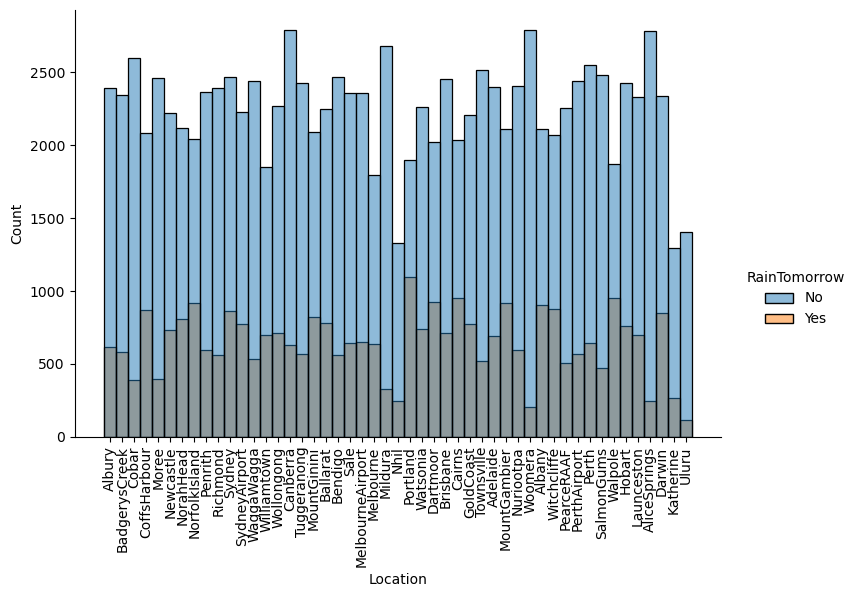

In [15]:
g = sns.displot(data=df_rain, x='Location', hue="RainTomorrow", height=5, aspect=1.5)
g.set_xticklabels(rotation=90)
g.set_titles("{col_name}")

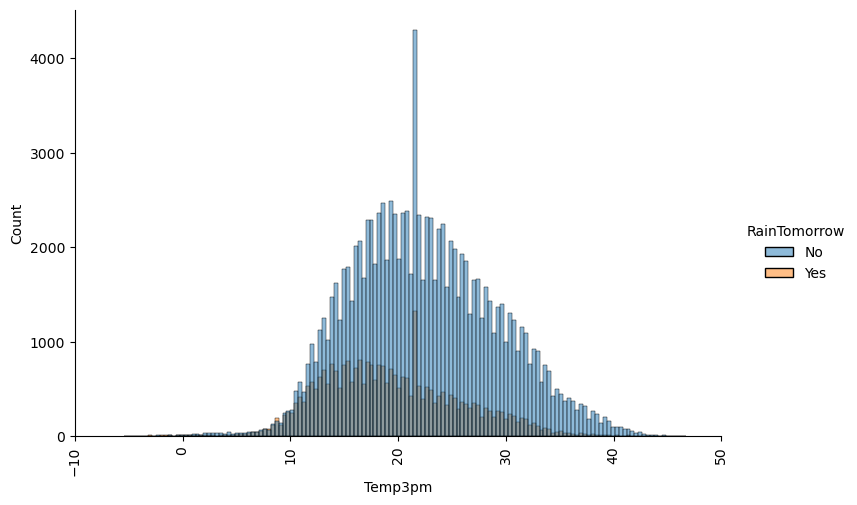

In [16]:
g = sns.displot(data=df_rain, x='Temp3pm', hue="RainTomorrow", height=5, aspect=1.5)
g.set_xticklabels(rotation=90)
g.set_titles("{col_name}")

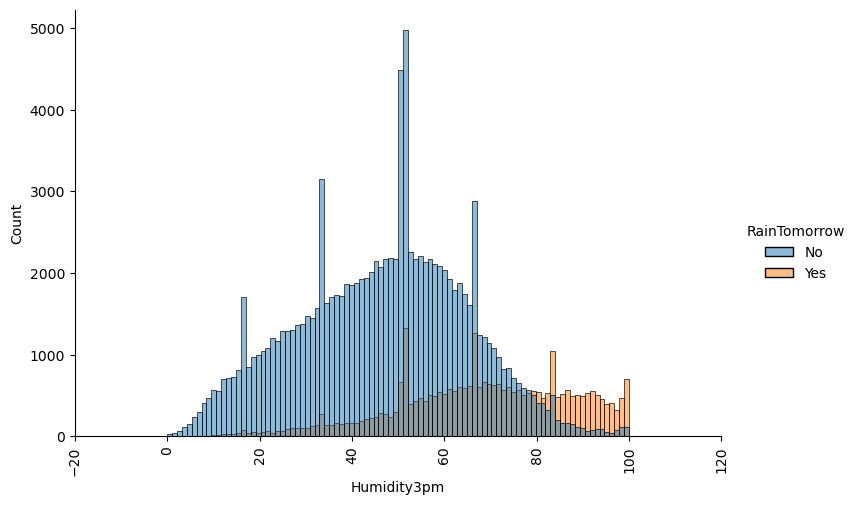

In [17]:
g = sns.displot(data=df_rain, x='Humidity3pm', hue="RainTomorrow", height=5, aspect=1.5)
g.set_xticklabels(rotation=90)
g.set_titles("{col_name}")

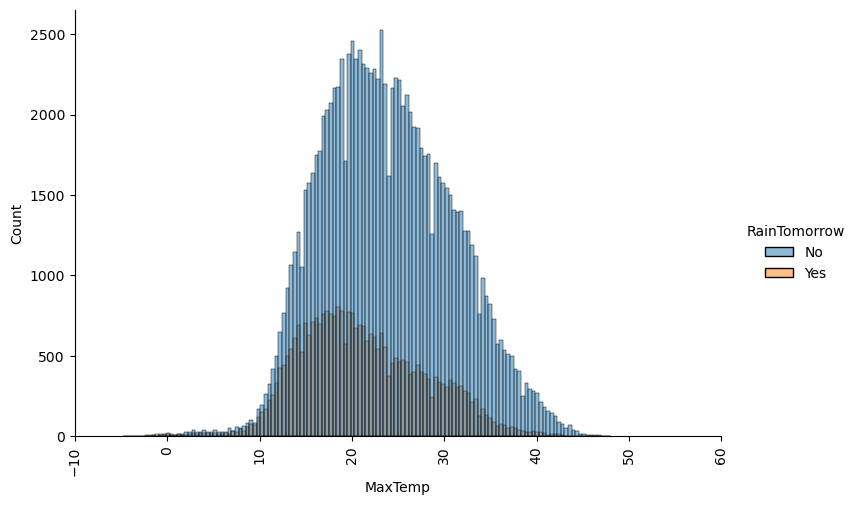

In [18]:
g = sns.displot(data=df_rain, x='MaxTemp', hue="RainTomorrow", height=5, aspect=1.5)
g.set_xticklabels(rotation=90)
g.set_titles("{col_name}")

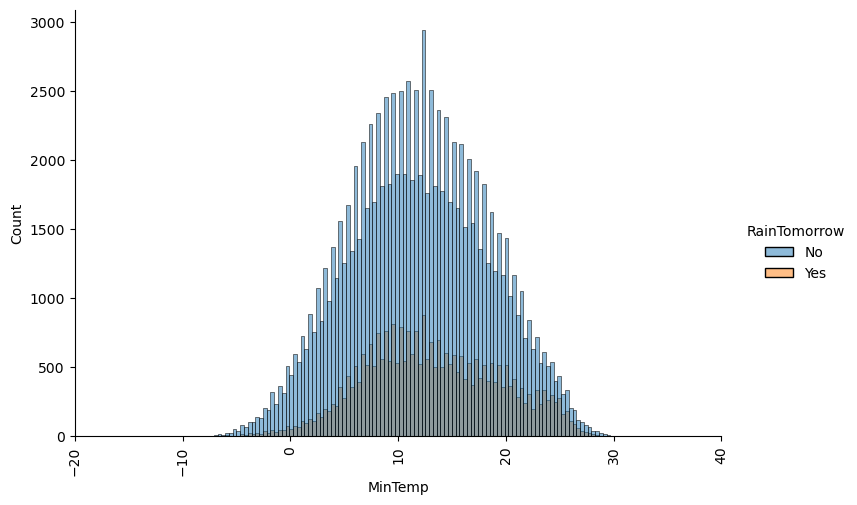

In [19]:
g = sns.displot(data=df_rain, x='MinTemp', hue="RainTomorrow", height=5, aspect=1.5)
g.set_xticklabels(rotation=90)
g.set_titles("{col_name}")

## Gráficos de dispersão, boxplots, violinplots

**As análises podem ser do datset inteiro ou de um recorte deles (e.g., análise para uma determinada região, gênero, etc).**

Plote 2 a 5 gráficos que julgar interessantes.

Procure fazer comparações (colocar 2 ou mais boxplot lado a lado, por exemplo).

Procure usar algumas visualizações um pouco diferentes daquelas vistas em sala. Por exemplo. gráficos que misturam pontos com boxplot ou violinplots. Algumas sugestões estão em um capítulo de livro postado no classroom (do livro Fundamentals of Data Visualization, de Claus O. Wilke).

Procure identificar situações pouco esperadas / menos óbvias, pois, se conseguir, isso será um grande diferencial.

Deixe comentários em markdown nas células que entecedem os gráficos.



### Comentário

- Umidade e Temperatura (plot 1): O boxplot mostra que dias que precedem chuva têm uma mediana de umidade muito superior (próximos de 70%). No scatterplot, a zona de chuva (pontos laranjas) fica nitidamente concentrada no topo, onde a umidade é alta e a temperatura é moderada.

- Pressão Atmosférica (plot 2): Embora as temperaturas mínimas sejam parecidas, o scatterplot de pressão revela que a chuva (laranja) se concentra em faixas de baixa pressão (abaixo de 1015-1020 hPa).

- Vento e Umidade (plot 3): O cruzamento mostra que ventos mais fortes combinados com alta umidade aumentam a chance de chuva. Percebe-se que a densidade de pontos laranjas aumenta conforme os ventos ficam mais fortes com humidade alta.

<Axes: xlabel='Temp3pm', ylabel='Humidity3pm'>

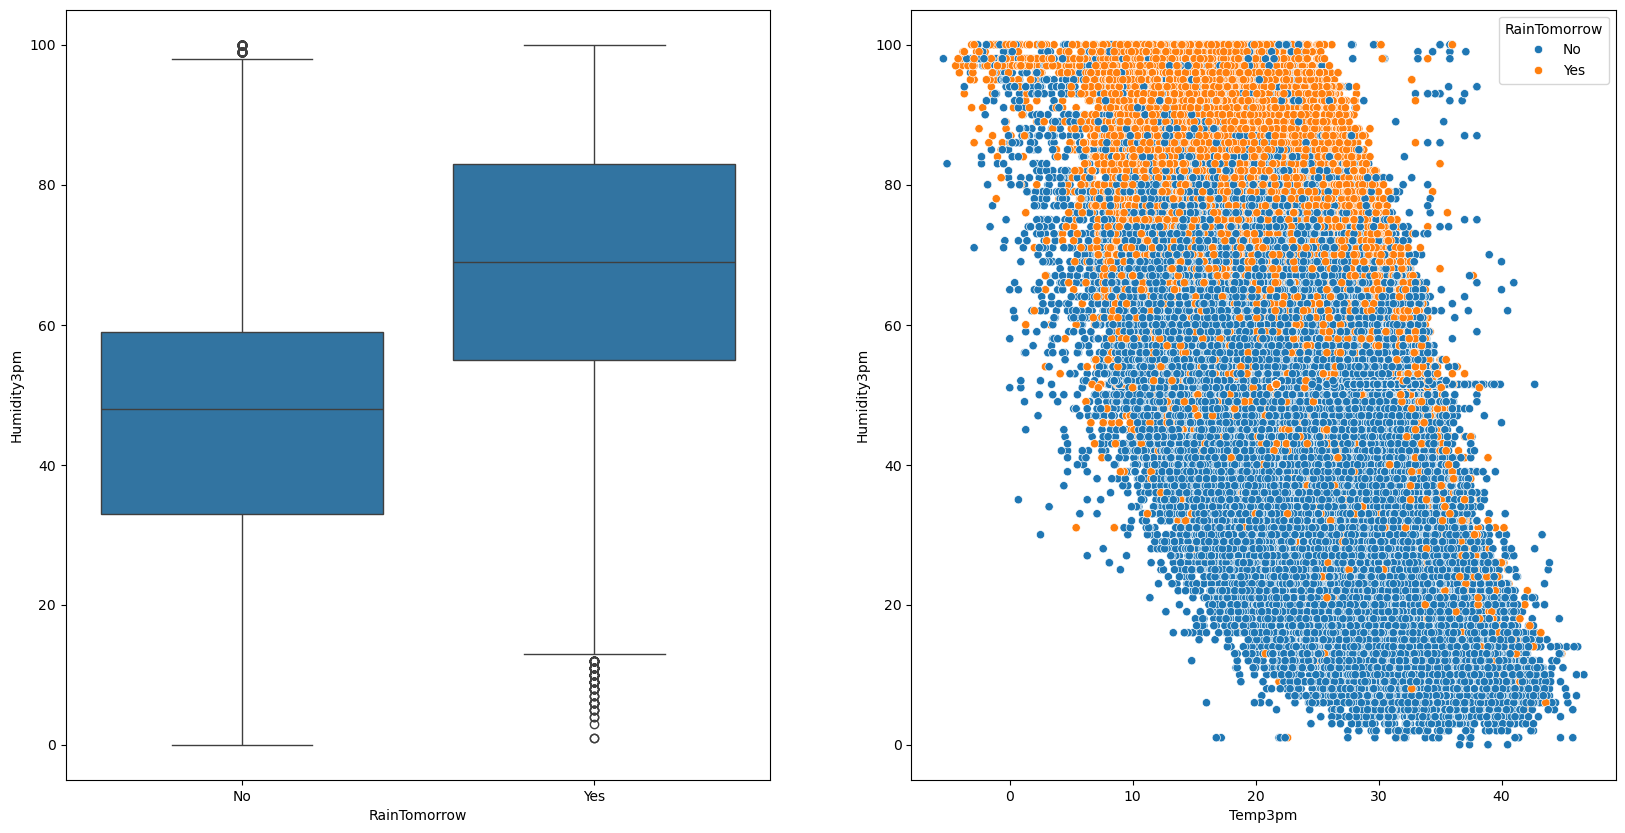

In [20]:
fig, axes = plt.subplots(1,2,figsize=(20,10))
sns.boxplot(df_rain,y='Humidity3pm',x='RainTomorrow',ax=axes[0])
sns.scatterplot(df_rain,x="Temp3pm", y="Humidity3pm",hue='RainTomorrow',ax=axes[1])

<Axes: xlabel='Pressure9am', ylabel='Pressure3pm'>

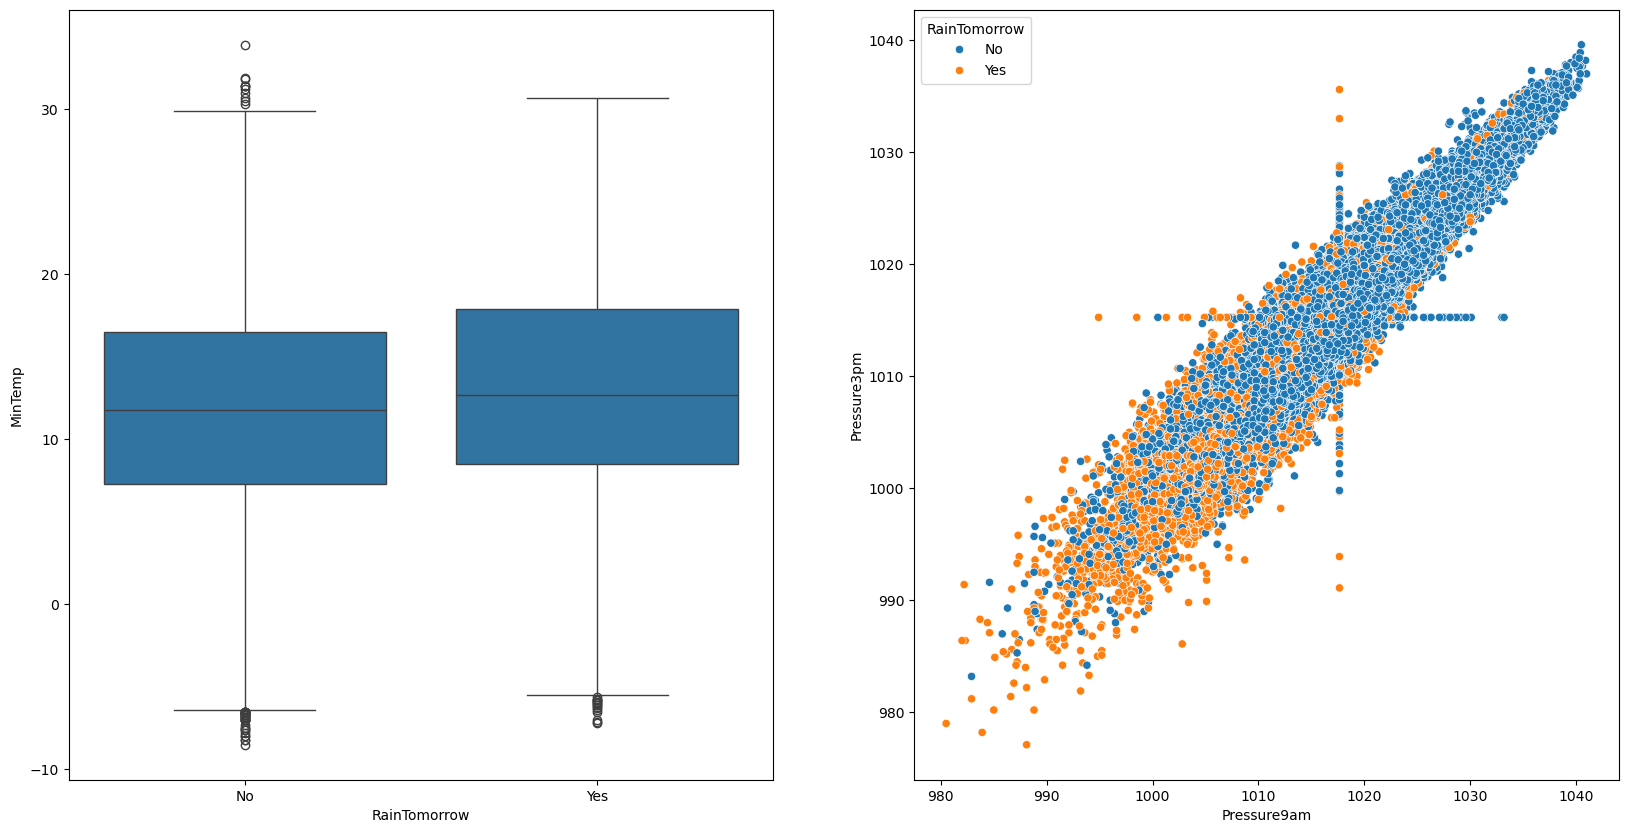

In [21]:
fig, axes = plt.subplots(1,2,figsize=(20,10))
sns.boxplot(df_rain,y='MinTemp',x='RainTomorrow',ax=axes[0])
sns.scatterplot(df_rain,x="Pressure9am", y="Pressure3pm",hue='RainTomorrow',ax=axes[1])

<Axes: xlabel='WindGustSpeed', ylabel='Humidity3pm'>

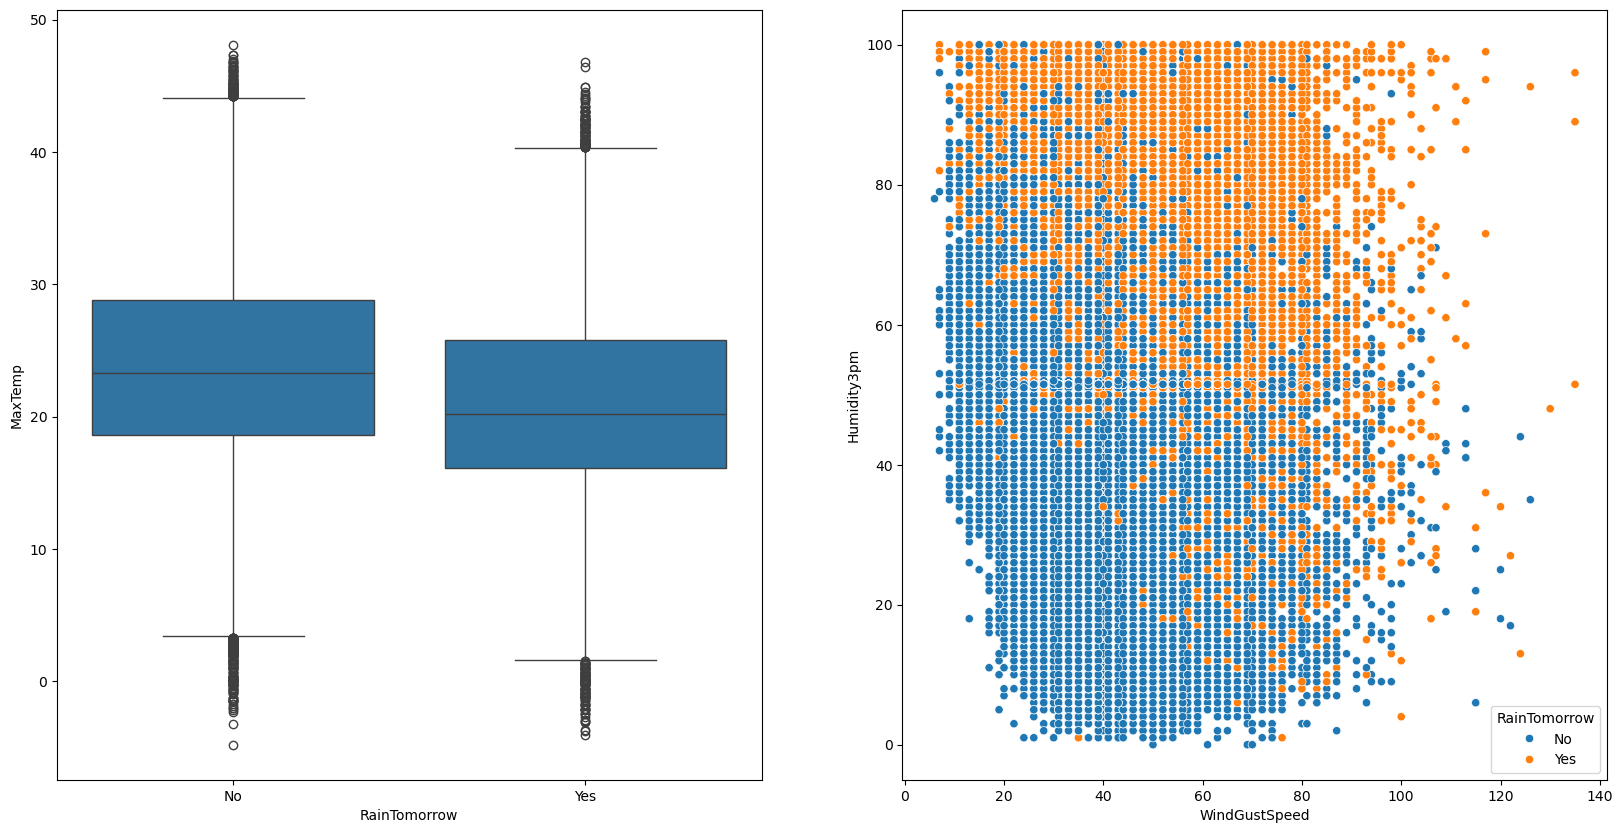

In [22]:
fig, axes = plt.subplots(1,2,figsize=(20,10))
sns.boxplot(df_rain,y='MaxTemp',x='RainTomorrow',ax=axes[0])
sns.scatterplot(df_rain,x="WindGustSpeed", y="Humidity3pm",hue='RainTomorrow',ax=axes[1])

# Parte B

## Correlações

**As análises podem ser do datset inteiro ou de um recorte deles (e.g., análise para uma determinada região, gênero, etc).**

Procure por correlações nos dados e mostre os valores encontrados. Fique à vontade para plotar gráficos antes de calcular a correlação, caso ache útil.

Justifique a estratégia utilizada para calcular.

Basta mostrar de 2 a 5 situações investigadas.

Lembre-se de comentar seus achados. Por exemplo:

*   Se a correlação encontrada foi relevante (se não é muito óbvia).
*   Ou se você esperaria ver uma correlação entre duas variáveis mas os dados não confirmaram. Ou seja, alguns dos itens que você vai adicionar ao notebook pode não ser uma correlação que encontrou, mas sim a confirmação de uma ausência de correlação.


Deixe comentários em markdown nas células que entecedem os códigos / gráficos.



### Quais são as features com maior correlação com a variável RainTomorrow no dataframe?

Para fazer essa correlação, dado que a variável RainTomorrow é do tipo str, decidi mapear o seu valor para 1 ou 0, e assim ter a condição de analisar a sua correlação em relação as variáveis numéricas

In [33]:
df_rain['RainTomorrow'] = df_rain['RainTomorrow'].apply(lambda x : 1 if x == "Yes" else 0)
df_rain['RainTomorrow'].head()


0    0
1    0
2    0
3    0
4    0
Name: RainTomorrow, dtype: int64

In [35]:
features_numericas = df_rain.select_dtypes(include=['number']).columns
df_rain[features_numericas].corr()['RainTomorrow'].sort_values(ascending=False).head(6)

RainTomorrow     1.000000
Humidity3pm      0.439678
Humidity9am      0.255158
Rainfall         0.236874
WindGustSpeed    0.225264
WindSpeed9am     0.090524
Name: RainTomorrow, dtype: float64

Os resultados mostram que as 5 variáveis com maior correlação com `RainTomorrow` foram `Humidity3pm`, `Humidity9am`, `Rainfall`, `WindGustSpeed` e `WindSpeed9am`.

Essas correlações fazem sentido no contexto do clima: maior umidade, ocorrência de chuva no dia atual e ventos mais intensos podem aumentar a chance de chuva no dia seguinte.

### Quais são as features com maior correlação com a variável RainToday no dataframe?

Para fazer essa correlação, dado que a variável RainToday é do tipo str, decidi mapear o seu valor para 1 ou 0, e assim ter a condição de analisar a sua correlação em relação as variáveis numéricas

In [39]:
df_rain['RainToday'] = df_rain['RainToday'].apply(lambda x: 1 if x == "Yes" else 0)      
df_rain['RainToday'].head()

0    0
1    0
2    0
3    0
4    0
Name: RainToday, dtype: int64

In [45]:
features_numericas = df_rain.select_dtypes(include=['number']).columns
df_rain[features_numericas].corr()['RainToday'].sort_values(ascending=False).head(6)

RainToday        1.000000
Rainfall         0.500286
Humidity3pm      0.370556
Humidity9am      0.348841
RainTomorrow     0.306555
WindGustSpeed    0.148244
Name: RainToday, dtype: float64

Para `RainToday`, as variáveis mais correlacionadas foram `Humidity3pm`, `Humidity9am`, `Rainfall`, `RainTomorrow` e `WindGustSpeed`.

A presença de `RainTomorrow` entre as mais correlacionadas também é ,na minha percepção, coerente, pois existe dependência temporal entre dias consecutivos (quando chove hoje, há chance maior de continuidade no dia seguinte em alguns cenários).

No geral, os resultados de `RainToday` e `RainTomorrow` são parecidos, reforçando que umidade, chuva recente e intensidade do vento são variáveis importantes para entender a ocorrência de chuva no dataset.

### Matriz de correlação

A matriz de correlação abaixo ajuda a confirmar os padrões vistos nos rankings acima e permite observar, ao mesmo tempo, relações fortes, moderadas e fracas entre as variáveis numéricas.

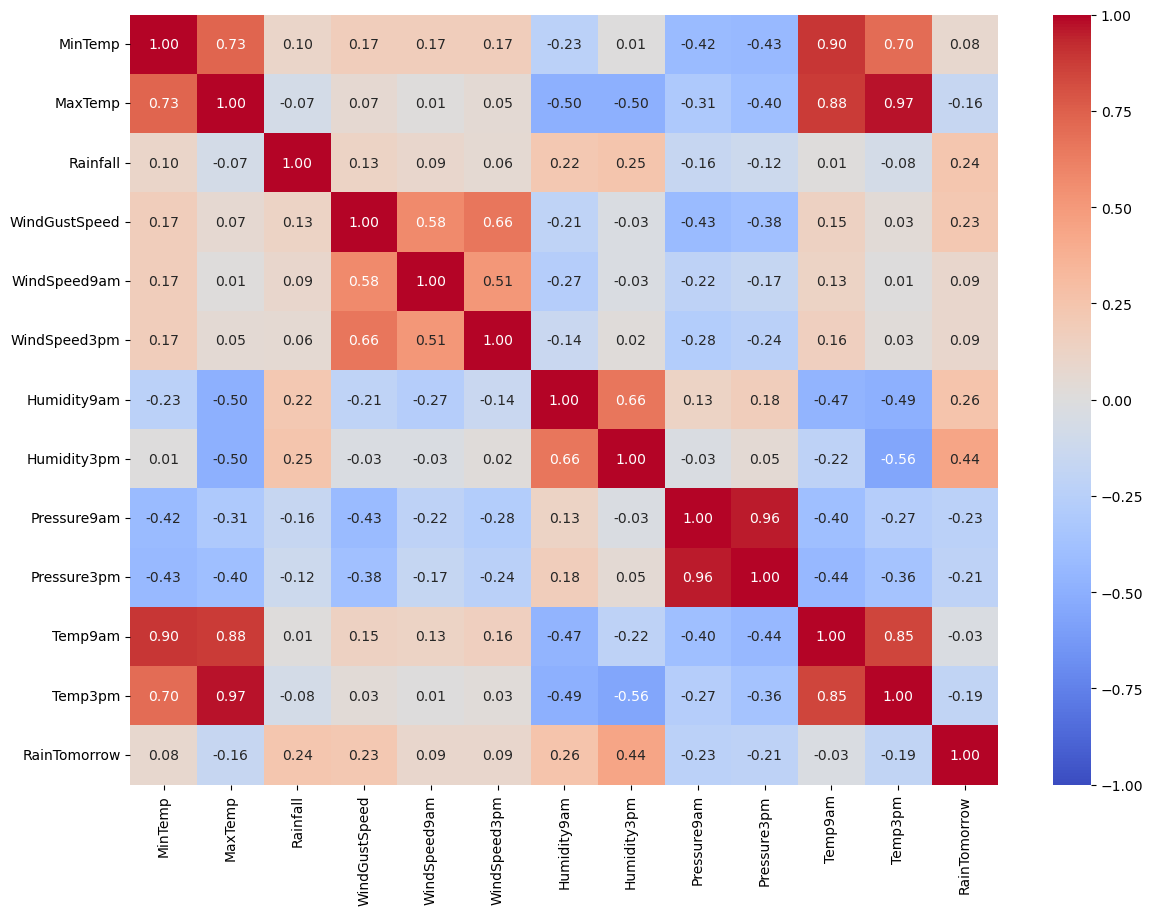

In [37]:
features_numericas = df_rain.select_dtypes(include=['number']).columns
corr_matrix = df_rain[features_numericas].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    vmin=-1,
    vmax=1,
    cmap='coolwarm',
    fmt='.2f',
    annot=True
)
plt.show()

# Implementações EXTRAS / RASCUNHO

Caso tenha implementado mais coisas do que foi pedido, coloque-as a partir deste ponto, para deixar a parte anterior mais limpa.

Fique totalmente à vontade para colocar qualquer coisa aqui, com ou sem comentários. É como o rascunho de uma prova... não será corrigido.

In [24]:
#

In [25]:
#